# Connected Domains & Hamiltonian Paths — A Deep Walkthrough

This notebook breaks down the algorithm behind the problem I explain in the PDF.
The goal: given a grid where some cells have been removed, find a set of paths that together
visit **every remaining cell exactly once**, while never crossing domain boundaries.



## The Big Picture

Here is the algorithm follows:

1. **Color the grid** like a checkerboard (black / white cells).
2. **Find connected components** — groups of cells that are connected to each other via 4-direction adjacency.
3. For each component, **partition it into subdomains** such that each subdomain has at most one more black cell than white (or vice versa). This is the tree-cutting step.
4. For each subdomain, **find the longest possible path** that visits every cell — a Hamiltonian path if we're lucky, or the best partial path otherwise.



In [1]:
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import random
import time

---
## Part 1 — The Board and Checkerboard Coloring

The grid is just a 2D array. Each cell gets a value:
- `+1` if `(row + col)` is even  → we'll call these **black** cells
- `-1` if `(row + col)` is odd   → these are **white** cells
- `0`  if the cell has been removed


**imbalance** of any group of cells simply by summing their values:
```
imbalance = sum(board[r][c] for (r,c) in group)
```
If the result is positive, there are more black cells. If negative, more white.
If zero, the group is balanced. 

In [2]:
def build_board(rows, cols, removed=None):
    """
    Build the grid. removed is a set of (r, c) tuples for cells to exclude.
    Returns a 2D list where each cell is +1, -1, or 0.
    """
    if removed is None:
        removed = set()
    board = []
    for r in range(rows):
        row = []
        for c in range(cols):
            if (r, c) in removed:
                row.append(0)          # removed cell
            elif (r + c) % 2 == 0:
                row.append(+1)         # black cell
            else:
                row.append(-1)         # white cell
        board.append(row)
    return board


# Let's build a small 5x5 board with a couple of cells removed
removed = {(1, 2), (3, 3)}
board = build_board(5, 5, removed)

print("Board values (+1 = black, -1 = white, 0 = removed):")
for row in board:
    print([f"{v:+d}" for v in row])

Board values (+1 = black, -1 = white, 0 = removed):
['+1', '-1', '+1', '-1', '+1']
['-1', '+1', '+0', '+1', '-1']
['+1', '-1', '+1', '-1', '+1']
['-1', '+1', '-1', '+0', '-1']
['+1', '-1', '+1', '-1', '+1']


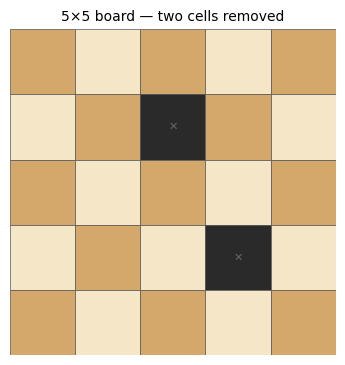

In [3]:
def draw_board(board, title="Board", domain_map=None, path_list=None, ax=None):
    """
    Simple matplotlib visualization of the board.
    domain_map: dict (r,c) -> domain_index, used to color domains.
    path_list:  list of lists of (r,c) tuples, one per domain.
    """
    rows = len(board)
    cols = len(board[0])
    # A palette of colors for domains
    palette = [
        "#4D96FF", "#FF6B6B", "#6BCB77", "#FFD93D",
        "#C084FC", "#F97316", "#2DD4BF", "#F43F5E"
    ]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(cols * 0.75, rows * 0.75))

    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=10, pad=6)

    for r in range(rows):
        for c in range(cols):
            v = board[r][c]
            # y is flipped so row 0 appears at the top
            y = rows - 1 - r

            if v == 0:
                color = "#2a2a2a"
                ax.text(c + 0.5, y + 0.5, "✕", ha='center', va='center',
                        fontsize=8, color='#666')
            elif domain_map and (r, c) in domain_map:
                idx = domain_map[(r, c)]
                color = palette[idx % len(palette)] + "88"  # semi-transparent
            else:
                color = "#d4a76a" if v == 1 else "#f5e6c8"  # classic chess colours

            rect = patches.Rectangle((c, y), 1, 1,
                                      facecolor=color, edgecolor='#555', linewidth=0.5)
            ax.add_patch(rect)

    # Draw paths
    if path_list:
        for pidx, path in enumerate(path_list):
            if not path or len(path) < 2:
                continue
            color = palette[pidx % len(palette)]
            xs = [c + 0.5 for (r, c) in path]
            ys = [rows - 1 - r + 0.5 for (r, c) in path]
            ax.plot(xs, ys, color=color, linewidth=2, zorder=3)
            # start marker
            ax.plot(xs[0], ys[0], 'o', color='#10b981', markersize=7, zorder=4)
            ax.plot(xs[-1], ys[-1], 'o', color='#ef4444', markersize=7, zorder=4)

    if standalone:
        plt.tight_layout()
        plt.show()


draw_board(board, title="5×5 board — two cells removed")

---
## Part 2 — Finding Connected Components

Two cells are **connected** if they are adjacent horizontally or vertically (no diagonals).
A **connected component** is a maximal group of cells where you can walk from any cell to any
other cell using only such steps — without stepping on a removed cell.

The standard algorithm for this is **BFS (Breadth-First Search)**. We pick an unvisited cell,
flood-fill outward using a queue, and collect everything reachable. Repeat until all cells
have been visited.

While we're doing the BFS we also count **black** and **white** cells in each component,
so we know the imbalance straight away.

In [4]:
DIRS = [(-1, 0), (1, 0), (0, -1), (0, 1)]   # up, down, left, right

def get_components(board):
    """
    Find all connected components in board via BFS.

    Returns a list of dicts, each containing:
      cells     : list of (r, c)
      black     : count of +1 cells
      white     : count of -1 cells
      imbalance : black - white  (positive means more black)
    """
    rows = len(board)
    cols = len(board[0])
    visited = [[False] * cols for _ in range(rows)]
    components = []

    for start_r in range(rows):
        for start_c in range(cols):
            if board[start_r][start_c] == 0 or visited[start_r][start_c]:
                continue

            # BFS from (start_r, start_c)
            queue = deque([(start_r, start_c)])
            visited[start_r][start_c] = True
            cells = []
            black = white = 0

            while queue:
                r, c = queue.popleft()
                cells.append((r, c))
                if board[r][c] == 1:
                    black += 1
                else:
                    white += 1

                for dr, dc in DIRS:
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < rows and 0 <= nc < cols \
                       and board[nr][nc] != 0 and not visited[nr][nc]:
                        visited[nr][nc] = True
                        queue.append((nr, nc))

            components.append({
                'cells': cells,
                'black': black,
                'white': white,
                'imbalance': black - white
            })

    return components


# Test it
board = build_board(5, 5, removed={(1, 2), (3, 3)})
comps = get_components(board)

print(f"Found {len(comps)} component(s)\n")
for i, c in enumerate(comps):
    print(f"  Component {i+1}: {len(c['cells'])} cells, "
          f"black={c['black']}, white={c['white']}, "
          f"imbalance={c['imbalance']:+d}")

Found 1 component(s)

  Component 1: 23 cells, black=12, white=11, imbalance=+1


---
## Part 3 —  Imbalance and The Lower Bound

Here is the key theoretical insight that drives the whole algorithm.

**Claim:** any path on a checkerboard grid must alternate between black and white cells.

This is because any two adjacent cells have opposite colors (that's literally what the
checkerboard pattern means). So every step along the path flips the color. A path of
length `n` visits cells in the sequence B-W-B-W-... or W-B-W-B-...

**Consequence:** in any single path, the black and white cell counts can differ by at most 1.
If a path visits `n` cells total:
- If `n` is even: exactly `n/2` black and `n/2` white.
- If `n` is odd: one color gets `(n+1)/2` and the other gets `(n-1)/2`.

So if a component has `B` black cells and `W` white cells with `|B - W| = k`, we **cannot**
cover it with fewer than `k` separate paths (because each path can "absorb" at most 1 unit
of imbalance). If `k = 0` we need at least 1 path (the component still has to be traversed).

That gives us the **lower bound** on the number of domains (and paths) we need:

```
lower_bound = sum( max(1, |imbalance|)  for each component )
```

The algorithm tries to achieve this bound exactly — i.e., one path per domain, and as few
domains as the math allows.

In [5]:
def compute_lower_bound(components):
    """
    The minimum number of non-crossing Hamiltonian paths needed
    to cover all cells. Each component contributes at least 1,
    and at least |imbalance| if imbalanced.
    """
    return sum(max(1, abs(c['imbalance'])) for c in components)


# Illustrate why imbalance forces multiple paths
print("Imbalance examples:")
examples = [
    ("4 black, 4 white",  0),
    ("5 black, 4 white",  1),
    ("6 black, 3 white",  3),
    ("3 black, 5 white", -2),
]
for label, imb in examples:
    needed = max(1, abs(imb))
    print(f"  {label:25s}  imbalance={imb:+d}  min paths needed = {needed}")

Imbalance examples:
  4 black, 4 white           imbalance=+0  min paths needed = 1
  5 black, 4 white           imbalance=+1  min paths needed = 1
  6 black, 3 white           imbalance=+3  min paths needed = 3
  3 black, 5 white           imbalance=-2  min paths needed = 2


---
## Part 4 — Domain Partitioning: The Tree-Cutting Algorithm

Given a connected component with imbalance `k > 1`, we need to split it into `k` domains,
each with imbalance exactly `+1` (or `-1` if the component has more white cells).

If `k = 0` we leave the component as one domain (it's already balanced).
If `k = 1` same thing — one domain, one path.

 The algorithm does something :

1. Build a **spanning tree** of the component using DFS. A spanning tree connects all `n` cells
   with exactly `n-1` edges and no cycles. We only need the tree structure — the original grid
   adjacency is still used for path-finding later.

2. Compute the **subtree sum** for each node: the sum of all `board` values in the subtree
   rooted at that node. This is done bottom-up in post-order.

3. To split off a domain of sum `+1`, find a **non-root node whose subtree sum equals +1**.
   Cutting the edge between that node and its parent separates the subtree (a connected
   subgraph with sum = +1) from the rest. We do this `k-1` times to get `k` domains.

A subtree of the spanning tree is always a connected subgraph
of the original grid. And because we update the remaining subtree sums after each cut,
subsequent cuts remain valid.



In [18]:
def build_spanning_tree(component_cells, board, rows, cols):
    """
    Build a spanning tree of the component using iterative DFS.
    Returns:
      idx_map   : dict (r,c) -> index in component_cells
      parent    : parent[i] = index of parent node (-1 for root)
      children  : children[i] = list of child indices
      postorder : nodes in post-order (leaves first, root last)
      raw_value : board value for each node
    """
    n = len(component_cells)
    idx_map = {(r, c): i for i, (r, c) in enumerate(component_cells)}

    # Adjacency list for the component
    adj = [[] for _ in range(n)]
    for i, (r, c) in enumerate(component_cells):
        for dr, dc in DIRS:
            key = (r + dr, c + dc)
            if key in idx_map:
                adj[i].append(idx_map[key])

    # Iterative DFS to build the tree (avoids Python recursion limit)
    parent = [-1] * n
    children = [[] for _ in range(n)]
    visited = [False] * n
    stack = [(0, -1)]          # (node, parent_node)
    visited[0] = True

    while stack:
        u, p = stack.pop()
        parent[u] = p
        for v in adj[u]:
            if v != p and not visited[v]:
                visited[v] = True
                children[u].append(v)
                stack.append((v, u))

    # Post-order traversal (children before parents)
    postorder = []
    st = [(0, False)]
    while st:
        u, processed = st.pop()
        if processed:
            postorder.append(u)
        else:
            st.append((u, True))
            for v in reversed(children[u]):
                st.append((v, False))

    raw_value = [board[r][c] for (r, c) in component_cells]

    return idx_map, parent, children, postorder, raw_value, adj


# Quick demo — show the subtree sums for a component
demo_board = build_board(4, 3, removed={(1, 1)})
demo_comps = get_components(demo_board)
print("Demo board components:")
for i, c in enumerate(demo_comps):
    print(f"  Component {i}: {len(c['cells'])} cells, imbalance={c['imbalance']:+d}")

# Pick the first component and build its spanning tree
comp = demo_comps[0]
idx_map, parent, children, postorder, raw_value, adj = build_spanning_tree(
    comp['cells'], demo_board, 4, 3
)

# Compute subtree sums bottom-up
f = raw_value[:]
for u in postorder:
    for v in children[u]:
        f[u] += f[v]

print("\nSubtree sums (f[i]) for each node:")
for i, (r, c) in enumerate(comp['cells']):
    print(f"  node {i} at ({r},{c}): board={raw_value[i]:+d}, subtree_sum={f[i]:+d}")

Demo board components:
  Component 0: 11 cells, imbalance=-1

Subtree sums (f[i]) for each node:
  node 0 at (0,0): board=+1, subtree_sum=-1
  node 1 at (1,0): board=-1, subtree_sum=-1
  node 2 at (0,1): board=-1, subtree_sum=-1
  node 3 at (2,0): board=+1, subtree_sum=+0
  node 4 at (0,2): board=+1, subtree_sum=+0
  node 5 at (3,0): board=-1, subtree_sum=-1
  node 6 at (2,1): board=-1, subtree_sum=+0
  node 7 at (1,2): board=-1, subtree_sum=-1
  node 8 at (3,1): board=+1, subtree_sum=+1
  node 9 at (2,2): board=+1, subtree_sum=+0
  node 10 at (3,2): board=-1, subtree_sum=-1


In [7]:
def tree_cutting_domains(component_cells, board, rows, cols):
    """
    Partition a single connected component into subdomains,
    each with imbalance = required_sign (+1 or -1).
    Components with imbalance 0 are returned as a single domain.

    Returns a list of cell-lists, one per domain.
    """
    n = len(component_cells)

    # ------ STEP 1: build the spanning tree ------
    idx_map, parent, children, postorder, raw_value, adj = build_spanning_tree(
        component_cells, board, rows, cols
    )

    total_sum = sum(raw_value)                       # imbalance of the whole component
    if total_sum == 0:
        # Already balanced — one domain is enough
        return [component_cells]

    required_sign = 1 if total_sum > 0 else -1
    cuts_needed   = abs(total_sum) - 1               # we need |imbalance| domains

    # ------ STEP 2: compute subtree sums bottom-up ------
    f = raw_value[:]                                 # f[u] = subtree sum rooted at u
    for u in postorder:
        for v in children[u]:
            f[u] += f[v]

    # ------ STEP 3: cut subtrees one at a time ------
    assigned  = [False] * n
    current_f = f[:]                                 # we'll update these after each cut
    cut_domains = []

    def find_cuttable_node(target):
        """
        Find a non-root node (not yet assigned) whose current subtree sum equals target.
        We scan in reverse post-order so we tend to pick smaller subtrees first.
        """
        for u in reversed(postorder):
            if u != 0 and not assigned[u] and current_f[u] == target:
                return u
        return -1

    for _ in range(cuts_needed):
        node = find_cuttable_node(required_sign)
        if node == -1:
            break                                    # shouldn't happen on valid input

        # Collect all nodes in the subtree rooted at `node`
        # (only unassigned nodes — previous cuts may have trimmed children)
        sub_queue = deque([node])
        sub_nodes = []
        sub_seen  = {node}

        while sub_queue:
            u = sub_queue.popleft()
            sub_nodes.append(u)
            for v in children[u]:
                if not assigned[v] and v not in sub_seen:
                    sub_seen.add(v)
                    sub_queue.append(v)

        # Mark them as assigned (they form one domain)
        for u in sub_nodes:
            assigned[u] = True
        cut_domains.append(sub_nodes)

        # Update ancestor subtree sums
        # The parent of `node` loses `required_sign` from its subtree
        ancestor = parent[node]
        while ancestor != -1:
            current_f[ancestor] -= required_sign
            ancestor = parent[ancestor]

    # Whatever's left (not yet assigned) forms the final domain
    remaining = [i for i in range(n) if not assigned[i]]
    if remaining:
        cut_domains.append(remaining)

    # Convert node indices back to (r, c) coordinates
    return [list({component_cells[i] for i in dom}) for dom in cut_domains]


# ----- Test it on a board where one component has imbalance 3 -----
# A 3x4 board with 2 corners removed creates strong imbalance
test_board = build_board(3, 4, removed={(0, 3), (2, 0)})
test_comps = get_components(test_board)

print("Test board:")
for row in test_board:
    print(" ", row)
print()

all_domains = []
for comp in test_comps:
    domains = tree_cutting_domains(comp['cells'], test_board, 3, 4)
    all_domains.extend(domains)
    print(f"Component (imbalance={comp['imbalance']:+d}) "
          f"→ split into {len(domains)} domain(s)")
    for i, d in enumerate(domains):
        s = sum(test_board[r][c] for r, c in d)
        print(f"   Domain {i+1}: {len(d)} cells, sum={s:+d}")

Test board:
  [1, -1, 1, 0]
  [-1, 1, -1, 1]
  [0, -1, 1, -1]

Component (imbalance=+0) → split into 1 domain(s)
   Domain 1: 10 cells, sum=+0


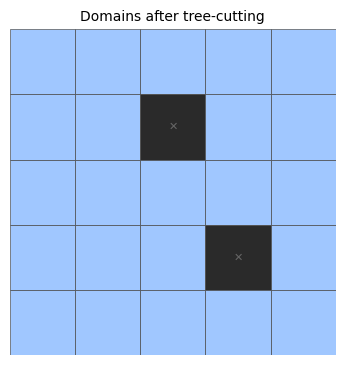

In [19]:
# Visualize the domain partitioning
domain_map = {}
for idx, dom in enumerate(all_domains):
    for cell in dom:
        domain_map[cell] = idx

draw_board(test_board, title="Domains after tree-cutting", domain_map=domain_map)

---
## Part 5 — The Hamiltonian Path Problem

A **Hamiltonian path** visits every vertex of a graph exactly once.
On a grid, that means walking through every cell in a domain without revisiting any.

This is an **NP-complete** problem in general, which means there is no known efficient
algorithm that works for all cases. The brute-force approach (try every permutation) is
completely impractical for grids larger than maybe 4×4.

The code uses two complementary strategies:

1. **Warnsdorff's heuristic** — a greedy algorithm that picks the next cell with the fewest
   onward options. Counterintuitively, going to the "most trapped" neighbor tends to avoid
   dead ends. This finds a complete path surprisingly often and very quickly.

2. **Iterative DFS with backtracking** — a proper exhaustive search, but with Warnsdorff
   ordering to prune the search tree. This is used when greedy fails. It has a time limit
   to stay interactive.



In [8]:
def build_adjacency(cells, rows, cols):
    """
    Build an adjacency list for path-finding within a domain.
    Returns adj where adj[i] = list of neighbor indices.
    """
    n = len(cells)
    flat_idx = {}                         # (r,c) -> index
    for i, (r, c) in enumerate(cells):
        flat_idx[(r, c)] = i

    adj = [[] for _ in range(n)]
    for i, (r, c) in enumerate(cells):
        for dr, dc in DIRS:
            nb = (r + dr, c + dc)
            if nb in flat_idx:
                adj[i].append(flat_idx[nb])

    return adj


# A small worked example so we can trace through the algorithm
small_board = build_board(3, 3)
small_comp  = get_components(small_board)[0]
small_adj   = build_adjacency(small_comp['cells'], 3, 3)

print("Cells and their neighbors in the 3×3 grid:")
for i, (r, c) in enumerate(small_comp['cells']):
    nb_coords = [small_comp['cells'][j] for j in small_adj[i]]
    print(f"  [{i}] ({r},{c}) → {nb_coords}")

Cells and their neighbors in the 3×3 grid:
  [0] (0,0) → [(1, 0), (0, 1)]
  [1] (1,0) → [(0, 0), (2, 0), (1, 1)]
  [2] (0,1) → [(1, 1), (0, 0), (0, 2)]
  [3] (2,0) → [(1, 0), (2, 1)]
  [4] (1,1) → [(0, 1), (2, 1), (1, 0), (1, 2)]
  [5] (0,2) → [(1, 2), (0, 1)]
  [6] (2,1) → [(1, 1), (2, 0), (2, 2)]
  [7] (1,2) → [(0, 2), (2, 2), (1, 1)]
  [8] (2,2) → [(1, 2), (2, 1)]


In [9]:
def warnsdorff_degree(node, visited, adj):
    """Count unvisited neighbors of node (Warnsdorff's 'onward degree')."""
    return sum(1 for v in adj[node] if not visited[v])


def can_reach_all_remaining(start, visited, adj, remaining_count):
    """
    Connectivity check: from `start`, can we reach exactly `remaining_count`
    unvisited cells? This is a BFS/DFS reachability test.

    Used to prune moves that would disconnect the rest of the board.
    If you move to a cell and it can no longer see all remaining cells,
    that move can never lead to a complete path — skip it.
    """
    if remaining_count == 0:
        return True
    seen = bytearray(len(adj))
    stack = [v for v in adj[start] if not visited[v]]
    for v in stack:
        seen[v] = 1
    reached = 0
    while stack:
        u = stack.pop()
        reached += 1
        for v in adj[u]:
            if not visited[v] and not seen[v]:
                seen[v] = 1
                stack.append(v)
    return reached == remaining_count


def greedy_warnsdorff(start, adj, randomize=False):
    """
    Greedy Warnsdorff path from `start`.

    At each step:
      1. Look at all unvisited neighbors.
      2. Filter out moves that would disconnect remaining cells (connectivity pruning).
      3. Among valid moves, pick the one with fewest onward neighbors (Warnsdorff).
      4. If randomize=True, occasionally pick from the top few instead of strictly best.
         This gives different paths on repeated runs.

    Returns the path as a list of indices.
    """
    n = len(adj)
    visited = bytearray(n)
    path = [start]
    visited[start] = 1

    while len(path) < n:
        u = path[-1]
        candidates = []

        for v in adj[u]:
            if visited[v]:
                continue
            visited[v] = 1
            # Only consider this move if remaining cells are still reachable
            if can_reach_all_remaining(v, visited, adj, n - len(path) - 1):
                degree = sum(1 for w in adj[v] if not visited[w])
                candidates.append((degree, v))
            visited[v] = 0

        if not candidates:
            break                          # dead end — greedy failed

        candidates.sort()                  # sort by onward degree (Warnsdorff)

        if randomize:
            # Pick from the top 1-3 candidates randomly for variation
            pick_from = min(len(candidates), random.randint(1, 3))
            _, next_node = random.choice(candidates[:pick_from])
        else:
            _, next_node = candidates[0]   # strict Warnsdorff

        visited[next_node] = 1
        path.append(next_node)

    return path


# Test on the 3x3 grid — should find a Hamiltonian path (it has one)
cells = small_comp['cells']
adj   = small_adj

path = greedy_warnsdorff(0, adj)
print(f"Greedy path from node 0: {path}")
print(f"Length: {len(path)} / {len(cells)} cells")
print(f"Coordinates: {[cells[i] for i in path]}")

Greedy path from node 0: [0, 1, 3, 6, 8, 7, 4, 2, 5]
Length: 9 / 9 cells
Coordinates: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (1, 2), (1, 1), (0, 1), (0, 2)]


### The DFS Fallback

Warnsdorff is fast but not perfect — it can fail on irregular grid shapes or when
there are very few valid Hamiltonian paths. When it does, we fall back to a proper
depth-first search with backtracking.

We also apply two pruning rules:
1. **Warnsdorff ordering** — try neighbors in order of ascending onward degree, same
   as the greedy heuristic. This doesn't change correctness but dramatically reduces
   the part of the search tree we explore.
2. **Time limit** — stop DFS after a fixed time budget and return the best path found so far.

We also track the **longest partial path** as we search, so even if no Hamiltonian
path exists we return something useful.

In [10]:
def ordered_neighbors(node, visited, adj):
    """
    Return unvisited neighbors of `node` sorted by their Warnsdorff degree.
    This is called each time we expand a DFS node.
    """
    result = []
    for v in adj[node]:
        if not visited[v]:
            degree = sum(1 for w in adj[v] if not visited[w])
            result.append((degree, v))
    result.sort()
    return [v for _, v in result]


def dfs_hamiltonian(start, adj, time_limit_sec=1.8):
    """
    Iterative DFS with backtracking to find a Hamiltonian path.

    Returns (best_path, is_complete) where:
      best_path   : list of node indices (the longest path found)
      is_complete : True if best_path visits all nodes
    """
    n = len(adj)
    deadline = time.perf_counter() + time_limit_sec

    visited  = bytearray(n)
    path_stk = [start]            # current path (node indices)
    dfs_stk  = [{                 # DFS state stack
        'node': start,
        'neighbors': ordered_neighbors(start, visited, adj),
        'next_idx': 0
    }]
    visited[start] = 1

    best_path = [start]
    best_len  = 1
    steps     = 0

    while dfs_stk:
        # Check timeout every 2048 steps
        steps += 1
        if steps & 2047 == 0 and time.perf_counter() > deadline:
            break

        state = dfs_stk[-1]

        # Found a complete Hamiltonian path!
        if len(path_stk) == n:
            best_path = path_stk[:]
            best_len  = n
            break

        # Track the best partial path seen
        if len(path_stk) > best_len:
            best_len  = len(path_stk)
            best_path = path_stk[:]

        if state['next_idx'] < len(state['neighbors']):
            # Advance to the next neighbor
            v = state['neighbors'][state['next_idx']]
            state['next_idx'] += 1

            if not visited[v]:
                visited[v] = 1
                path_stk.append(v)
                dfs_stk.append({
                    'node': v,
                    'neighbors': ordered_neighbors(v, visited, adj),
                    'next_idx': 0
                })
        else:
            # Backtrack
            dfs_stk.pop()
            if path_stk:
                last = path_stk.pop()
                visited[last] = 0

    is_complete = (best_len == n)
    return best_path, is_complete


# Test
path, complete = dfs_hamiltonian(0, small_adj)
print(f"DFS path: {path}")
print(f"Complete: {complete}")
print(f"Coordinates: {[cells[i] for i in path]}")

DFS path: [0, 1, 3, 6, 8, 7, 4, 2, 5]
Complete: True
Coordinates: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (1, 2), (1, 1), (0, 1), (0, 2)]


---
## Part 6 — The Full Solver

The original JavaScript tries several start points because the quality of Warnsdorff's result
can depend on where you start. The solver:

1. First tries **greedy Warnsdorff** from every start that looks promising
   (degree-1 nodes first, since they can only be endpoints).
2. Then tries **randomized Warnsdorff** with multiple random seeds for diversity.
3. Finally falls back to **exhaustive DFS** from the best start candidates.

The moment a complete Hamiltonian path is found, it stops and returns it.

Board has 1 component(s)
Total domains after partitioning: 1
  Domain 1: 23 cells → ✅ complete


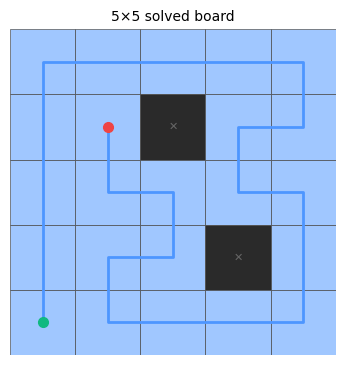

In [11]:
def find_best_path(cells, rows, cols, forced_start=None, time_limit=1.8):
    """
    Main path solver for a single domain.

    Strategy:
      Phase 1: Greedy Warnsdorff from every promising start.
      Phase 2: Randomized Warnsdorff for variety.
      Phase 3: Exhaustive DFS with backtracking.

    Returns (path_coords, is_complete, coverage)
      path_coords : list of (r, c) in visit order
      is_complete : True if all cells covered
      coverage    : number of cells visited
    """
    n = len(cells)
    if n == 0:
        return [], False, 0
    if n == 1:
        return [cells[0]], True, 1

    adj = build_adjacency(cells, rows, cols)

    # If a forced start cell is given, find its index
    forced_idx = -1
    if forced_start and forced_start in cells:
        forced_idx = cells.index(forced_start)

    # Build the list of start candidates
    # Degree-1 nodes (corners/dead-ends) must be path endpoints
    degree_one = [i for i in range(n) if len(adj[i]) <= 1]
    all_starts = sorted(range(n), key=lambda i: len(adj[i]))

    if forced_idx >= 0:
        start_candidates = [forced_idx]
    else:
        start_candidates = list(dict.fromkeys(degree_one + all_starts))

    best_path = None
    best_len  = 0

    # ── Phase 1: strict Warnsdorff ──
    for start in start_candidates:
        path = greedy_warnsdorff(start, adj, randomize=False)
        if len(path) > best_len:
            best_len  = len(path)
            best_path = [cells[i] for i in path]
        if len(path) == n:
            return best_path, True, n

    # ── Phase 2: randomized Warnsdorff ──
    random_tries = 220 if n > 46 else 60
    for t in range(random_tries):
        start = start_candidates[t % len(start_candidates)]
        path  = greedy_warnsdorff(start, adj, randomize=True)
        if len(path) > best_len:
            best_len  = len(path)
            best_path = [cells[i] for i in path]
        if len(path) == n:
            return best_path, True, n

    # ── Phase 3: exhaustive DFS ──
    for start in start_candidates:
        path, complete = dfs_hamiltonian(start, adj, time_limit)
        if len(path) > best_len:
            best_len  = len(path)
            best_path = [cells[i] for i in path]
        if complete:
            return best_path, True, n

    return best_path, False, best_len


# ── Run it on the test board ──
test_board = build_board(5, 5, removed={(1, 2), (3, 3)})
test_comps = get_components(test_board)

print(f"Board has {len(test_comps)} component(s)")

all_domains = []
for comp in test_comps:
    sub_domains = tree_cutting_domains(comp['cells'], test_board, 5, 5)
    all_domains.extend(sub_domains)

print(f"Total domains after partitioning: {len(all_domains)}")

paths      = []
domain_map = {}

for idx, domain in enumerate(all_domains):
    for cell in domain:
        domain_map[cell] = idx

    path_coords, complete, coverage = find_best_path(domain, 5, 5)
    paths.append(path_coords)

    status = "✅ complete" if complete else f"⚠ partial ({coverage}/{len(domain)})"
    print(f"  Domain {idx+1}: {len(domain)} cells → {status}")

draw_board(test_board, title="5×5 solved board", domain_map=domain_map, path_list=paths)

---
## Part 7 — Validating the Partition

Before running the expensive path-finder, the original code checks that the tree-cutting
produced a valid partition. A valid partition satisfies:

- Every domain is **connected** (you can walk between any two cells in the domain).
- Domains are **non-overlapping** and together cover the whole component.
- Each domain has the **correct imbalance** (`+1`, `-1`, or `0`).

If the partition is invalid (which shouldn't happen with correct input but is a good
safety net), the component is returned as a single domain with a warning flag.

In [12]:
def is_connected(cells):
    """Check that a list of cells forms a connected region."""
    if len(cells) <= 1:
        return True
    cell_set = set(cells)
    visited  = {cells[0]}
    queue    = deque([cells[0]])
    while queue:
        r, c = queue.popleft()
        for dr, dc in DIRS:
            nb = (r + dr, c + dc)
            if nb in cell_set and nb not in visited:
                visited.add(nb)
                queue.append(nb)
    return len(visited) == len(cells)


def validate_partition(domains, component_cells, board, required_sign):
    """
    Sanity-check the partition produced by tree_cutting_domains.

    required_sign: +1 or -1 if imbalanced, 0 if balanced.
    Returns True if the partition is valid.
    """
    expected = set(component_cells)
    seen     = set()

    for domain in domains:
        # Must be non-empty and connected
        if not domain or not is_connected(domain):
            return False

        # Must have the right imbalance
        s = sum(board[r][c] for r, c in domain)
        if required_sign != 0 and s != required_sign:
            return False
        if required_sign == 0 and abs(s) > 1:
            return False

        # Cells must be from the component and not repeated
        for cell in domain:
            if cell not in expected or cell in seen:
                return False
            seen.add(cell)

    return seen == expected    # all component cells must be covered


# Verify our earlier partition
b = build_board(3, 4, removed={(0, 3), (2, 0)})
comps = get_components(b)
for comp in comps:
    s = comp['imbalance']
    domains = tree_cutting_domains(comp['cells'], b, 3, 4)
    req = (1 if s > 0 else -1) if s != 0 else 0
    valid = validate_partition(domains, comp['cells'], b, req)
    print(f"Component (imbalance={s:+d}): partition valid = {valid}")

Component (imbalance=+0): partition valid = True


---
## Part 8 — Putting It All Together

Here's the complete pipeline wrapped in one function, mirroring what `solveDomainsAndPaths()`
does .

Then we'll run it on a few interesting configurations and visualize the results side by side.

Stats: {'components': 1, 'lower_bound': 1, 'domains': 1, 'gap': 0, 'full_paths': 1, 'partial_paths': 0}


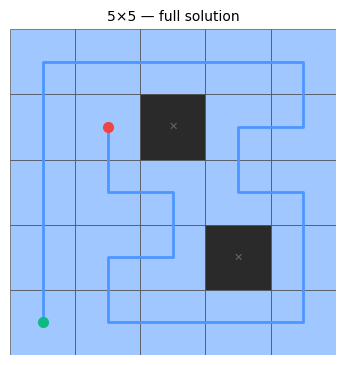

In [13]:
def solve(rows, cols, removed=None, forced_start=None):
    """
    Full pipeline:
      1. Build board
      2. Find components
      3. Partition into domains
      4. Find Hamiltonian path per domain

    Returns (board, domains, paths, stats)
    """
    if removed is None:
        removed = set()

    board = build_board(rows, cols, removed)
    comps = get_components(board)

    lower_bound = sum(max(1, abs(c['imbalance'])) for c in comps)

    all_domains = []
    for comp in comps:
        abs_imb = abs(comp['imbalance'])
        if abs_imb == 0:
            all_domains.append(comp['cells'])
        else:
            sub = tree_cutting_domains(comp['cells'], board, rows, cols)
            sign = 1 if comp['imbalance'] > 0 else -1
            if validate_partition(sub, comp['cells'], board, sign):
                all_domains.extend(sub)
            else:
                all_domains.append(comp['cells'])   # fallback: don't split

    paths    = []
    results  = []
    domain_map = {}

    for idx, domain in enumerate(all_domains):
        for cell in domain:
            domain_map[cell] = idx

        use_forced = forced_start if forced_start in domain else None
        path_coords, complete, coverage = find_best_path(
            domain, rows, cols, forced_start=use_forced
        )
        paths.append(path_coords)
        results.append({
            'cells': domain,
            'path': path_coords,
            'complete': complete,
            'coverage': coverage
        })

    full = sum(1 for r in results if r['complete'])
    stats = {
        'components': len(comps),
        'lower_bound': lower_bound,
        'domains': len(all_domains),
        'gap': len(all_domains) - lower_bound,
        'full_paths': full,
        'partial_paths': len(results) - full,
    }
    return board, domain_map, paths, stats


board, domain_map, paths, stats = solve(5, 5, removed={(1, 2), (3, 3)})
print("Stats:", stats)
draw_board(board, title="5×5 — full solution", domain_map=domain_map, path_list=paths)

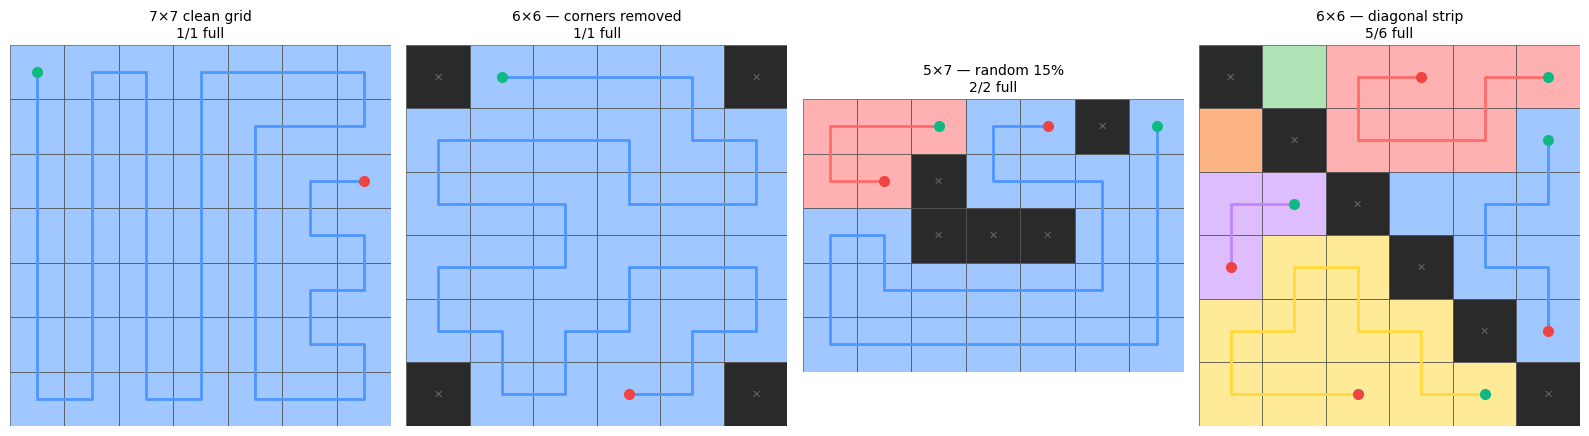

In [14]:
# ----- Side-by-side examples -----

examples = [
    ("7×7 clean grid",          7, 7, set()),
    ("6×6 — corners removed",   6, 6, {(0,0),(0,5),(5,0),(5,5)}),
    ("5×7 — random 15%",        5, 7, None),   # None = generate randomly
    ("6×6 — diagonal strip",    6, 6, {(i, i) for i in range(6)}),
]

fig, axes = plt.subplots(1, len(examples), figsize=(16, 4.5))

for ax, (title, rows, cols, removed) in zip(axes, examples):
    if removed is None:
        total   = rows * cols
        all_cells = [(r, c) for r in range(rows) for c in range(cols)]
        removed = set(map(tuple, random.sample(all_cells, int(total * 0.15))))

    board, domain_map, paths, stats = solve(rows, cols, removed)

    full_label = f"{stats['full_paths']}/{stats['domains']} full"
    draw_board(board,
               title=f"{title}\n{full_label}",
               domain_map=domain_map,
               path_list=paths,
               ax=ax)

plt.tight_layout()
plt.show()

---
## Part 9 — Complexity Analysis


| Step | Complexity | Notes |
|------|-----------|-------|
| Build board | O(n) | trivial |
| Find components (BFS) | O(n) | each cell visited once |
| Tree-cutting | O(n) | one DFS pass, then linear cuts |
| Validate partition | O(n) | linear scan |
| Build adjacency | O(n) | each cell has at most 4 neighbors |
| Warnsdorff greedy | O(n²) per start | degree computation at each step |
| DFS backtracking | O(n! / pruning) | worst case exponential |


In [15]:
import time

print("Timing the solver on different grid sizes:\n")
print(f"{'Grid':15s} {'Cells':6s} {'Domains':8s} {'Full':6s} {'Time (ms)':10s}")
print("-" * 50)

for rows, cols in [(4,4), (5,5), (6,6), (7,7), (8,8), (10,10), (12,12)]:
    # Random 10% removal
    all_cells = [(r, c) for r in range(rows) for c in range(cols)]
    removed   = set(map(tuple, random.sample(all_cells, int(len(all_cells) * 0.10))))

    t0    = time.perf_counter()
    _, _, _, stats = solve(rows, cols, removed)
    elapsed_ms = (time.perf_counter() - t0) * 1000

    cells = rows * cols - len(removed)
    print(f"{rows}×{cols}{'':10s} {cells:6d} {stats['domains']:8d} "
          f"{stats['full_paths']:6d} {elapsed_ms:10.1f}")

Timing the solver on different grid sizes:

Grid            Cells  Domains  Full   Time (ms) 
--------------------------------------------------
4×4               15        1      1        0.3
5×5               23        1      1        1.7
6×6               33        1      1        3.0
7×7               45        1      1     7365.0
8×8               58        1      1       13.9
10×10               90        2      1   149959.3
12×12              130        4      3   215035.8


---
## Part 10 — Edge Cases Worth Knowing About

A few situations that need special handling:

### 1. Disconnected grid
Removing cells can split the grid into multiple components. The algorithm handles each
component independently .

### 2. Isolated cells
A single removed cell in the middle can create a 1-cell component. A single-cell path
is trivially "Hamiltonian" (it covers its one cell). These are handled correctly since
we return early when `n == 1`.

### 3. Degree-1 nodes must be path endpoints
If a cell has only one neighbor (a dead-end), it **must** be either the start or end
of any Hamiltonian path through its domain. If a domain has more than two degree-1 nodes,
no Hamiltonian path exists. The algorithm implicitly handles this by prioritizing degree-1
nodes as start candidates.

### 4. Balanced but even-length domains
A balanced domain (imbalance = 0) always has an even number of cells. A Hamiltonian
path on an even number of cells always starts and ends on opposite colors. This means
the start and end are forced to be different colors — a useful sanity check.

### 5. Tree-cutting failure
If the validation check fails the component is treated as a single domain. The path-finder will still do
its best, even if it can't find a Hamiltonian path.

Disconnected grid stats:
  Components : 2
  Domains    : 2
  Full paths : 2


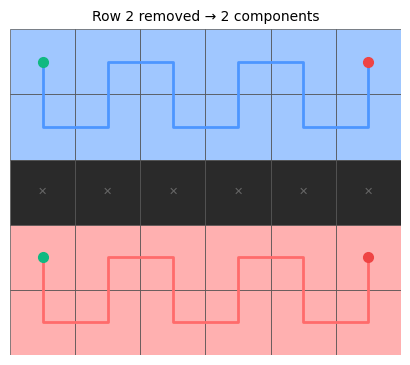

In [16]:
# Demonstrate the disconnected grid case
# Removing a full row splits the grid in two
disconnected = {(2, c) for c in range(6)}   # remove entire row 2
board, domain_map, paths, stats = solve(5, 6, disconnected)

print(f"Disconnected grid stats:")
print(f"  Components : {stats['components']}")
print(f"  Domains    : {stats['domains']}")
print(f"  Full paths : {stats['full_paths']}")

draw_board(board,
           title=f"Row 2 removed → {stats['components']} components",
           domain_map=domain_map,
           path_list=paths)

T-shape (3 dead ends):
  Domains: 3, Full paths: 3
  Path 1: length 1 — ✅ complete
  Path 2: length 3 — ✅ complete
  Path 3: length 1 — ✅ complete


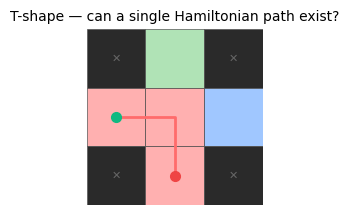

In [17]:
# What happens when a domain has three degree-1 nodes?
# Create a T-shape — it has three dead ends
# Keep only (0,1),(1,0),(1,1),(1,2),(2,1) from a 3x3 grid
keep = {(0,1),(1,0),(1,1),(1,2),(2,1)}
all_3x3 = {(r,c) for r in range(3) for c in range(3)}
t_removed = all_3x3 - keep

board_t, dm_t, paths_t, stats_t = solve(3, 3, t_removed)
print("T-shape (3 dead ends):")
print(f"  Domains: {stats_t['domains']}, Full paths: {stats_t['full_paths']}")
for i, p in enumerate(paths_t):
    print(f"  Path {i+1}: length {len(p)} — {'✅ complete' if stats_t['full_paths'] > i else '⚠ partial'}")

draw_board(board_t,
           title="T-shape — can a single Hamiltonian path exist?",
           domain_map=dm_t,
           path_list=paths_t)

---
## Summary

Here's the whole thing in a paragraph:

We color the grid like a checkerboard and observe that any grid path alternates colors.
This means a group of cells with black–white imbalance `k` needs **at least `k` paths**
to cover it. We use BFS to find connected components, then a **spanning-tree algorithm**
to slice each component into exactly the minimum number of **balanced domains**.
For each domain we run **Warnsdorff's greedy heuristic** (go to the most-trapped neighbor)
which finds a complete Hamiltonian path surprisingly often. When it fails,
**backtracking DFS** with the same neighbor ordering takes over, stopping when it either
finds a full path or times out — returning the longest partial path found.

The whole thing runs in tens of milliseconds for typical 7×7 grids,
and stays interactive up to 12×12.

---

### Key things to take away

- **Checkerboard imbalance is the central constraint.** 
- **Spanning trees are surprisingly powerful.** 
- **Warnsdorff's heuristic is remarkably effective** 
- **Iterative DFS beats recursive DFS**
- **Connectivity pruning**